# Part 2g: Custom Training Loops in Deep Learning

## Overview

In this notebook, we'll explore how to create **custom training loops** in both TensorFlow/Keras and PyTorch. Custom training loops give you complete control over the training process, enabling advanced techniques like gradient accumulation, mixed precision training, and custom optimization strategies.

### Topics Covered:
1. **TensorFlow GradientTape** - Low-level training control in TensorFlow
2. **PyTorch Manual Training** - Forward/backward pass in PyTorch
3. **Fashion MNIST Example** - Complete training loop implementation
4. **Advanced Techniques** - Gradient clipping, accumulation, mixed precision
5. **Custom Training Features** - Learning rate warmup, custom logging

### Why Custom Training Loops?
- Full control over training dynamics
- Implement research techniques not in standard APIs
- Debug and understand model behavior
- Custom logging and visualization

In [1]:
# Install required packages (for Google Colab)
!pip install -q tensorflow torch matplotlib seaborn tqdm

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")

TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128


---

## 1. Understanding Training Loops

### Standard Training Loop Components

```
for epoch in range(num_epochs):
    for batch in dataloader:
        1. Forward pass: predictions = model(inputs)
        2. Compute loss: loss = loss_fn(predictions, targets)
        3. Backward pass: compute gradients
        4. Update weights: optimizer.step()
```

### Comparison: High-level vs Low-level API

| Aspect | High-level (model.fit) | Low-level (Custom Loop) |
|--------|------------------------|-------------------------|
| Control | Limited | Full |
| Complexity | Simple | More code |
| Flexibility | Standard training only | Any custom logic |
| Debugging | Harder | Easier |

---

## 2. TensorFlow GradientTape

TensorFlow's `GradientTape` records operations for automatic differentiation. It allows you to compute gradients of any computation with respect to any trainable variables.

In [3]:
# Basic GradientTape example
print("Basic GradientTape Example:")
print("=" * 50)

# Create a simple variable
x = tf.Variable(3.0)

# Record operations
with tf.GradientTape() as tape:
    y = x ** 2  # y = x^2

# Compute gradient: dy/dx = 2x
dy_dx = tape.gradient(y, x)

print(f"x = {x.numpy()}")
print(f"y = x^2 = {y.numpy()}")
print(f"dy/dx = 2x = {dy_dx.numpy()} (expected: 6.0)")

Basic GradientTape Example:
x = 3.0
y = x^2 = 9.0
dy/dx = 2x = 6.0 (expected: 6.0)


In [4]:
# Multiple gradients with persistent tape
print("\nPersistent GradientTape (multiple gradients):")
print("=" * 50)

x = tf.Variable(2.0)

with tf.GradientTape(persistent=True) as tape:
    y1 = x ** 2
    y2 = x ** 3

dy1_dx = tape.gradient(y1, x)
dy2_dx = tape.gradient(y2, x)

print(f"x = {x.numpy()}")
print(f"dy1/dx (d(x^2)/dx = 2x) = {dy1_dx.numpy()}")
print(f"dy2/dx (d(x^3)/dx = 3x^2) = {dy2_dx.numpy()}")

# Clean up persistent tape
del tape


Persistent GradientTape (multiple gradients):
x = 2.0
dy1/dx (d(x^2)/dx = 2x) = 4.0
dy2/dx (d(x^3)/dx = 3x^2) = 12.0


### 2.1 Custom Training Step Function (TensorFlow)

In [5]:
class CustomTrainer:
    """
    Custom training class for TensorFlow models.

    Provides full control over training loop with:
    - Custom training step
    - Metrics tracking
    - Learning rate scheduling
    - Gradient clipping
    """

    def __init__(self, model, optimizer, loss_fn, metrics=None,
                 gradient_clip_norm=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics or []
        self.gradient_clip_norm = gradient_clip_norm

        # History tracking
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_accuracy': [], 'val_accuracy': []
        }

    @tf.function
    def train_step(self, x, y):
        """
        Single training step with GradientTape.

        Using @tf.function decorator for graph compilation
        and better performance.
        """
        with tf.GradientTape() as tape:
            # Forward pass
            predictions = self.model(x, training=True)

            # Compute loss
            loss = self.loss_fn(y, predictions)

            # Add regularization losses if any
            if self.model.losses:
                loss += tf.add_n(self.model.losses)

        # Compute gradients
        gradients = tape.gradient(loss, self.model.trainable_variables)

        # Gradient clipping
        if self.gradient_clip_norm is not None:
            gradients, _ = tf.clip_by_global_norm(gradients, self.gradient_clip_norm)

        # Apply gradients
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))

        return loss, predictions

    @tf.function
    def test_step(self, x, y):
        """Single evaluation step (no gradient computation)."""
        predictions = self.model(x, training=False)
        loss = self.loss_fn(y, predictions)
        return loss, predictions

    def fit(self, train_data, val_data=None, epochs=10, verbose=True):
        """
        Training loop.

        Parameters:
        -----------
        train_data : tf.data.Dataset
            Training dataset
        val_data : tf.data.Dataset
            Validation dataset
        epochs : int
            Number of training epochs
        """
        for epoch in range(epochs):
            start_time = time.time()

            # Training
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            for x_batch, y_batch in train_data:
                loss, predictions = self.train_step(x_batch, y_batch)
                train_loss += loss.numpy() * x_batch.shape[0]

                # Compute accuracy - cast y_batch to int64 for comparison
                pred_labels = tf.argmax(predictions, axis=1)
                y_batch_int64 = tf.cast(y_batch, tf.int64)
                train_correct += tf.reduce_sum(
                    tf.cast(pred_labels == y_batch_int64, tf.int32)
                ).numpy()
                train_total += x_batch.shape[0]

            train_loss /= train_total
            train_acc = train_correct / train_total

            # Validation
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            if val_data is not None:
                for x_batch, y_batch in val_data:
                    loss, predictions = self.test_step(x_batch, y_batch)
                    val_loss += loss.numpy() * x_batch.shape[0]

                    pred_labels = tf.argmax(predictions, axis=1)
                    y_batch_int64 = tf.cast(y_batch, tf.int64)
                    val_correct += tf.reduce_sum(
                        tf.cast(pred_labels == y_batch_int64, tf.int32)
                    ).numpy()
                    val_total += x_batch.shape[0]

                val_loss /= val_total
                val_acc = val_correct / val_total
            else:
                val_loss, val_acc = 0.0, 0.0

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_accuracy'].append(val_acc)

            elapsed = time.time() - start_time

            if verbose:
                print(f"Epoch {epoch+1}/{epochs} - {elapsed:.1f}s - "
                      f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - "
                      f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        return self.history

---

## 3. Fashion MNIST Example

Let's implement complete custom training loops for Fashion MNIST in both frameworks.

In [6]:
# Load and preprocess Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize and reshape
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Add channel dimension for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Class names for visualization
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training data: {X_train.shape}")
print(f"Test data: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28, 1)
Test data: (10000, 28, 28, 1)


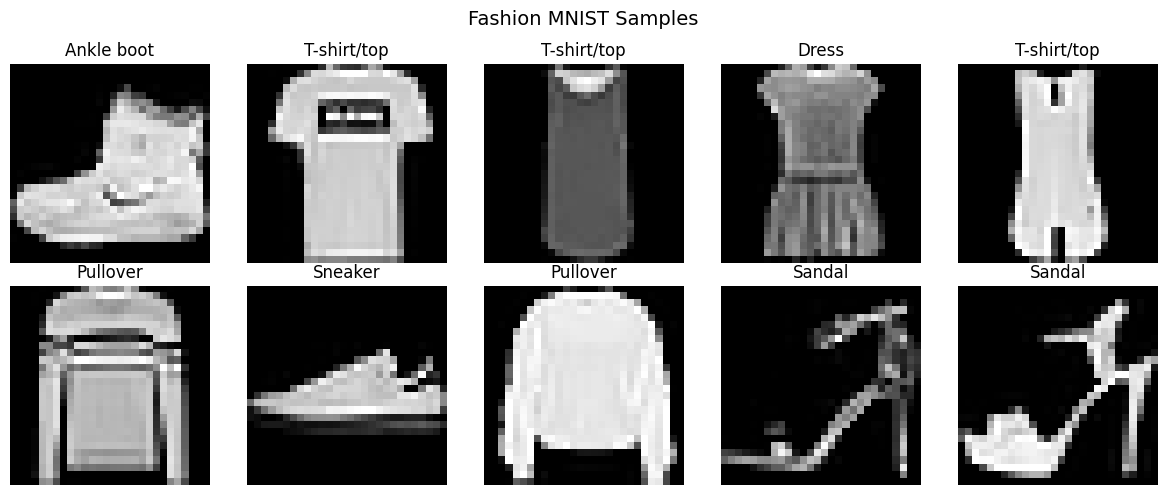

In [7]:
# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.suptitle('Fashion MNIST Samples', fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 TensorFlow Custom Training Loop

In [8]:
# Create TensorFlow datasets
BATCH_SIZE = 64

train_dataset_tf = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset_tf = train_dataset_tf.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset_tf = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset_tf = test_dataset_tf.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Training batches: {len(train_dataset_tf)}")
print(f"Test batches: {len(test_dataset_tf)}")

Training batches: 938
Test batches: 157


In [9]:
# Create CNN model
def create_cnn_model_tf():
    return keras.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(28, 28, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

model_tf = create_cnn_model_tf()
model_tf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# Train with custom training loop
print("Training TensorFlow model with custom training loop:")
print("=" * 60)

# Initialize trainer
trainer = CustomTrainer(
    model=model_tf,
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss_fn=keras.losses.SparseCategoricalCrossentropy(),
    gradient_clip_norm=1.0
)

# Train
history_tf = trainer.fit(
    train_data=train_dataset_tf,
    val_data=test_dataset_tf,
    epochs=10,
    verbose=True
)

Training TensorFlow model with custom training loop:
Epoch 1/10 - 14.3s - loss: 0.5183 - accuracy: 0.8145 - val_loss: 0.5014 - val_accuracy: 0.8196
Epoch 2/10 - 7.1s - loss: 0.3273 - accuracy: 0.8851 - val_loss: 0.3131 - val_accuracy: 0.8848
Epoch 3/10 - 7.3s - loss: 0.2832 - accuracy: 0.8980 - val_loss: 0.2947 - val_accuracy: 0.8933
Epoch 4/10 - 7.2s - loss: 0.2570 - accuracy: 0.9080 - val_loss: 0.2850 - val_accuracy: 0.8975
Epoch 5/10 - 7.1s - loss: 0.2385 - accuracy: 0.9158 - val_loss: 0.3587 - val_accuracy: 0.8646
Epoch 6/10 - 7.1s - loss: 0.2252 - accuracy: 0.9190 - val_loss: 0.4119 - val_accuracy: 0.8614
Epoch 7/10 - 7.0s - loss: 0.2147 - accuracy: 0.9232 - val_loss: 0.2595 - val_accuracy: 0.9093
Epoch 8/10 - 7.1s - loss: 0.2031 - accuracy: 0.9258 - val_loss: 0.2692 - val_accuracy: 0.9084
Epoch 9/10 - 7.1s - loss: 0.1900 - accuracy: 0.9315 - val_loss: 0.2725 - val_accuracy: 0.9032
Epoch 10/10 - 7.1s - loss: 0.1829 - accuracy: 0.9343 - val_loss: 0.2903 - val_accuracy: 0.8990


### 3.2 PyTorch Custom Training Loop

In [11]:
# Prepare PyTorch data
# Reshape for PyTorch (N, C, H, W)
X_train_pt = torch.tensor(X_train.transpose(0, 3, 1, 2), dtype=torch.float32)
y_train_pt = torch.tensor(y_train, dtype=torch.long)
X_test_pt = torch.tensor(X_test.transpose(0, 3, 1, 2), dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

train_dataset_pt = TensorDataset(X_train_pt, y_train_pt)
train_loader_pt = DataLoader(train_dataset_pt, batch_size=BATCH_SIZE, shuffle=True)

test_dataset_pt = TensorDataset(X_test_pt, y_test_pt)
test_loader_pt = DataLoader(test_dataset_pt, batch_size=BATCH_SIZE)

print(f"Training batches: {len(train_loader_pt)}")
print(f"Test batches: {len(test_loader_pt)}")

Training batches: 938
Test batches: 157


In [12]:
# PyTorch CNN model
class CNNModelPyTorch(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.dropout1 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128, 128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

model_pt = CNNModelPyTorch()
print(model_pt)

CNNModelPyTorch(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gap): AdaptiveAvgPool2d(output_size=1)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [13]:
class PyTorchTrainer:
    """
    Custom training class for PyTorch models.
    """

    def __init__(self, model, optimizer, criterion, device='cpu',
                 gradient_clip_norm=None):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.gradient_clip_norm = gradient_clip_norm

        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_accuracy': [], 'val_accuracy': []
        }

    def train_epoch(self, train_loader):
        """Train for one epoch."""
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(self.device), target.to(self.device)

            # Zero gradients
            self.optimizer.zero_grad()

            # Forward pass
            output = self.model(data)

            # Compute loss
            loss = self.criterion(output, target)

            # Backward pass
            loss.backward()

            # Gradient clipping
            if self.gradient_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    self.model.parameters(),
                    self.gradient_clip_norm
                )

            # Update weights
            self.optimizer.step()

            # Statistics
            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, test_loader):
        """Evaluate on test data."""
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in test_loader:
            data, target = data.to(self.device), target.to(self.device)

            output = self.model(data)
            loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def fit(self, train_loader, test_loader, epochs=10, verbose=True):
        """Full training loop."""
        for epoch in range(epochs):
            start_time = time.time()

            # Train
            train_loss, train_acc = self.train_epoch(train_loader)

            # Evaluate
            val_loss, val_acc = self.evaluate(test_loader)

            elapsed = time.time() - start_time

            # Store history
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_accuracy'].append(train_acc)
            self.history['val_accuracy'].append(val_acc)

            if verbose:
                print(f"Epoch {epoch+1}/{epochs} - {elapsed:.1f}s - "
                      f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - "
                      f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        return self.history

In [14]:
# Train PyTorch model
print("\nTraining PyTorch model with custom training loop:")
print("=" * 60)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize trainer
trainer_pt = PyTorchTrainer(
    model=model_pt,
    optimizer=torch.optim.Adam(model_pt.parameters(), lr=0.001),
    criterion=nn.CrossEntropyLoss(),
    device=device,
    gradient_clip_norm=1.0
)

# Train
history_pt = trainer_pt.fit(
    train_loader=train_loader_pt,
    test_loader=test_loader_pt,
    epochs=10,
    verbose=True
)


Training PyTorch model with custom training loop:
Using device: cuda
Epoch 1/10 - 5.0s - loss: 0.6682 - accuracy: 0.7588 - val_loss: 0.6189 - val_accuracy: 0.7699
Epoch 2/10 - 4.0s - loss: 0.4343 - accuracy: 0.8450 - val_loss: 0.4430 - val_accuracy: 0.8435
Epoch 3/10 - 4.0s - loss: 0.3781 - accuracy: 0.8653 - val_loss: 0.4419 - val_accuracy: 0.8394
Epoch 4/10 - 4.0s - loss: 0.3475 - accuracy: 0.8764 - val_loss: 0.3743 - val_accuracy: 0.8695
Epoch 5/10 - 4.0s - loss: 0.3204 - accuracy: 0.8861 - val_loss: 0.3323 - val_accuracy: 0.8821
Epoch 6/10 - 4.0s - loss: 0.3024 - accuracy: 0.8930 - val_loss: 0.3104 - val_accuracy: 0.8881
Epoch 7/10 - 4.0s - loss: 0.2875 - accuracy: 0.8976 - val_loss: 0.3627 - val_accuracy: 0.8715
Epoch 8/10 - 4.0s - loss: 0.2758 - accuracy: 0.9028 - val_loss: 0.3290 - val_accuracy: 0.8857
Epoch 9/10 - 4.0s - loss: 0.2666 - accuracy: 0.9050 - val_loss: 0.2911 - val_accuracy: 0.8926
Epoch 10/10 - 4.0s - loss: 0.2556 - accuracy: 0.9083 - val_loss: 0.2786 - val_accura

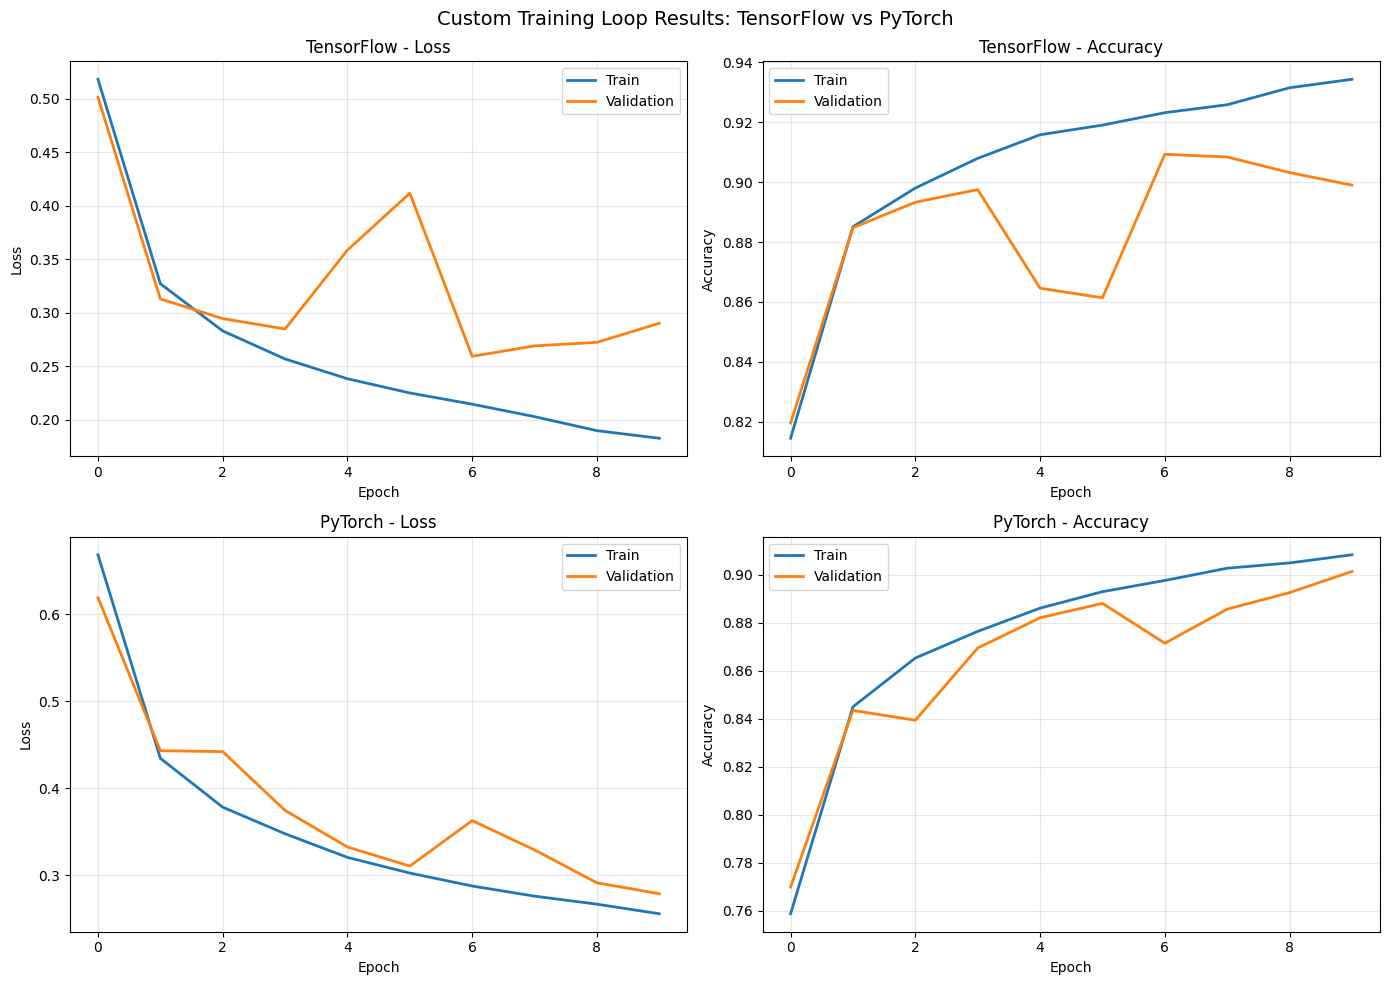

In [15]:
# Compare results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# TensorFlow training
axes[0, 0].plot(history_tf['train_loss'], label='Train', linewidth=2)
axes[0, 0].plot(history_tf['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('TensorFlow - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_tf['train_accuracy'], label='Train', linewidth=2)
axes[0, 1].plot(history_tf['val_accuracy'], label='Validation', linewidth=2)
axes[0, 1].set_title('TensorFlow - Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# PyTorch training
axes[1, 0].plot(history_pt['train_loss'], label='Train', linewidth=2)
axes[1, 0].plot(history_pt['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('PyTorch - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history_pt['train_accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(history_pt['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].set_title('PyTorch - Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Custom Training Loop Results: TensorFlow vs PyTorch', fontsize=14)
plt.tight_layout()
plt.show()

---

## 4. Advanced Training Techniques

### 4.1 Gradient Accumulation

Useful when training with large effective batch sizes on limited memory.

In [16]:
def train_with_gradient_accumulation_tf(model, dataset, optimizer, loss_fn,
                                         accumulation_steps=4):
    """
    TensorFlow training with gradient accumulation.

    Accumulates gradients over multiple mini-batches before updating,
    effectively simulating larger batch sizes.
    """
    # Initialize gradient accumulators
    accumulated_gradients = [tf.zeros_like(v) for v in model.trainable_variables]

    step = 0
    total_loss = 0.0

    for x_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            predictions = model(x_batch, training=True)
            loss = loss_fn(y_batch, predictions)
            # Scale loss by accumulation steps
            scaled_loss = loss / accumulation_steps

        # Compute gradients
        gradients = tape.gradient(scaled_loss, model.trainable_variables)

        # Accumulate gradients
        accumulated_gradients = [
            acc_grad + grad
            for acc_grad, grad in zip(accumulated_gradients, gradients)
        ]

        total_loss += loss.numpy()
        step += 1

        # Apply gradients every accumulation_steps
        if step % accumulation_steps == 0:
            optimizer.apply_gradients(
                zip(accumulated_gradients, model.trainable_variables)
            )
            # Reset accumulators
            accumulated_gradients = [
                tf.zeros_like(v) for v in model.trainable_variables
            ]

    return total_loss / step

print("Gradient Accumulation function defined.")

Gradient Accumulation function defined.


In [17]:
def train_with_gradient_accumulation_pt(model, dataloader, optimizer, criterion,
                                         accumulation_steps=4, device='cpu'):
    """
    PyTorch training with gradient accumulation.
    """
    model.train()
    model.to(device)

    optimizer.zero_grad()
    total_loss = 0.0

    for step, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)

        # Forward pass
        output = model(data)
        loss = criterion(output, target)

        # Scale loss
        scaled_loss = loss / accumulation_steps
        scaled_loss.backward()

        total_loss += loss.item()

        # Update weights every accumulation_steps
        if (step + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

    return total_loss / len(dataloader)

print("PyTorch Gradient Accumulation function defined.")

PyTorch Gradient Accumulation function defined.


### 4.2 Learning Rate Warmup

In [18]:
class WarmupScheduler:
    """
    Learning rate warmup scheduler.

    Gradually increases learning rate from 0 to target_lr over warmup_steps,
    then follows a decay schedule.
    """

    def __init__(self, optimizer, warmup_steps, target_lr, decay_type='constant'):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.target_lr = target_lr
        self.decay_type = decay_type
        self.current_step = 0

    def step(self):
        """Update learning rate."""
        self.current_step += 1

        if self.current_step <= self.warmup_steps:
            # Linear warmup
            lr = self.target_lr * (self.current_step / self.warmup_steps)
        else:
            # Decay phase
            if self.decay_type == 'constant':
                lr = self.target_lr
            elif self.decay_type == 'cosine':
                decay_steps = self.current_step - self.warmup_steps
                total_decay_steps = 1000  # Assume total steps
                lr = self.target_lr * 0.5 * (1 + np.cos(np.pi * decay_steps / total_decay_steps))
            else:
                lr = self.target_lr

        # Update optimizer learning rate
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr

        return lr

    def get_lr(self):
        return self.optimizer.param_groups[0]['lr']

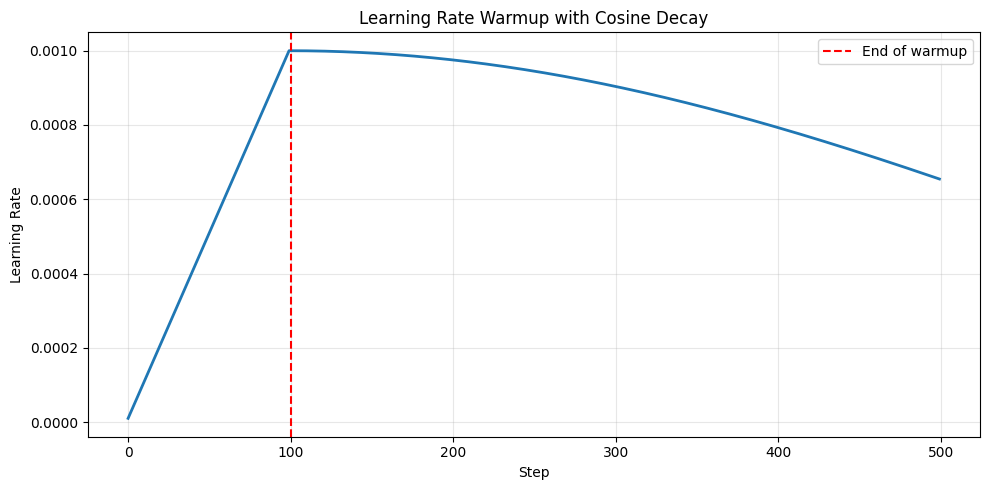

In [19]:
# Visualize warmup schedule
fig, ax = plt.subplots(figsize=(10, 5))

# Simulate warmup
dummy_model = nn.Linear(10, 1)
dummy_optimizer = torch.optim.SGD(dummy_model.parameters(), lr=0.0)

scheduler = WarmupScheduler(
    optimizer=dummy_optimizer,
    warmup_steps=100,
    target_lr=0.001,
    decay_type='cosine'
)

lrs = []
for _ in range(500):
    lr = scheduler.step()
    lrs.append(lr)

ax.plot(lrs, linewidth=2)
ax.axvline(x=100, color='r', linestyle='--', label='End of warmup')
ax.set_xlabel('Step')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Warmup with Cosine Decay')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 Mixed Precision Training (PyTorch)

In [20]:
def train_mixed_precision_pt(model, dataloader, optimizer, criterion,
                              device='cuda', epochs=1):
    """
    PyTorch mixed precision training using AMP.

    Uses automatic mixed precision for faster training on GPUs.
    """
    if not torch.cuda.is_available():
        print("CUDA not available, falling back to regular training")
        return train_regular(model, dataloader, optimizer, criterion, device)

    model.to(device)
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for data, target in dataloader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()

            # Mixed precision forward pass
            with torch.cuda.amp.autocast():
                output = model(data)
                loss = criterion(output, target)

            # Scaled backward pass
            scaler.scale(loss).backward()

            # Scaled optimizer step
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

print("Mixed precision training function defined.")

Mixed precision training function defined.


---

## 5. Complete Training Pipeline with Progress Bar

In [21]:
class AdvancedTrainer:
    """
    Advanced PyTorch trainer with all features.
    """

    def __init__(self, model, optimizer, criterion, scheduler=None,
                 device='cpu', gradient_clip_norm=None):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.device = device
        self.gradient_clip_norm = gradient_clip_norm
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

    def train_epoch(self, train_loader, epoch):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1} [Train]')
        for data, target in pbar:
            data, target = data.to(self.device), target.to(self.device)

            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()

            if self.gradient_clip_norm:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.gradient_clip_norm)

            self.optimizer.step()

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{correct/total:.4f}'})

        return total_loss / total, correct / total

    @torch.no_grad()
    def evaluate(self, test_loader):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in test_loader:
            data, target = data.to(self.device), target.to(self.device)
            output = self.model(data)
            loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def fit(self, train_loader, test_loader, epochs):
        best_val_acc = 0.0

        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch(train_loader, epoch)
            val_loss, val_acc = self.evaluate(test_loader)

            # Learning rate scheduling
            current_lr = self.optimizer.param_groups[0]['lr']
            if self.scheduler:
                self.scheduler.step()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['lr'].append(current_lr)

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = self.model.state_dict().copy()

            print(f"\nEpoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
                  f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}, LR={current_lr:.6f}")

        print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")
        return self.history

In [22]:
# Demo advanced trainer
print("Training with Advanced Trainer:")
print("=" * 60)

# Create fresh model
model_advanced = CNNModelPyTorch()
optimizer_adv = torch.optim.Adam(model_advanced.parameters(), lr=0.001)
scheduler_adv = torch.optim.lr_scheduler.StepLR(optimizer_adv, step_size=3, gamma=0.5)

advanced_trainer = AdvancedTrainer(
    model=model_advanced,
    optimizer=optimizer_adv,
    criterion=nn.CrossEntropyLoss(),
    scheduler=scheduler_adv,
    device=device,
    gradient_clip_norm=1.0
)

history_advanced = advanced_trainer.fit(train_loader_pt, test_loader_pt, epochs=5)

Training with Advanced Trainer:


Epoch 1 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 1: Train Loss=0.6775, Train Acc=0.7550, Val Loss=0.4365, Val Acc=0.8452, LR=0.001000


Epoch 2 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 2: Train Loss=0.4316, Train Acc=0.8477, Val Loss=0.3906, Val Acc=0.8621, LR=0.001000


...


Epoch 3: Train Loss=0.3780, Train Acc=0.8671, Val Loss=0.4430, Val Acc=0.8490, LR=0.001000


Epoch 4 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 4: Train Loss=0.3223, Train Acc=0.8862, Val Loss=0.3174, Val Acc=0.8869, LR=0.000500


Epoch 5 [Train]:   0%|          | 0/938 [00:00<?, ?it/s]


Epoch 5: Train Loss=0.3023, Train Acc=0.8932, Val Loss=0.3041, Val Acc=0.8951, LR=0.000500

Best Validation Accuracy: 0.8951


---

## 6. Summary and Best Practices

In [23]:
import pandas as pd

# Summary table
summary_data = {
    'Technique': ['GradientTape (TF)', 'Manual Loop (PT)', 'Grad Accumulation',
                  'LR Warmup', 'Mixed Precision', 'Gradient Clipping'],
    'Purpose': ['Record ops for autodiff', 'Full control over training',
                'Simulate large batches', 'Stable early training',
                'Faster GPU training', 'Prevent exploding gradients'],
    'When to Use': ['Custom TF training', 'Custom PT training',
                    'Limited GPU memory', 'Transformers/large models',
                    'GPU training', 'RNNs/deep networks'],
    'Framework': ['TensorFlow', 'PyTorch', 'Both', 'Both', 'PyTorch (AMP)', 'Both']
}

df = pd.DataFrame(summary_data)
print("Custom Training Loop Techniques:")
print("=" * 90)
print(df.to_string(index=False))

Custom Training Loop Techniques:
        Technique                     Purpose               When to Use     Framework
GradientTape (TF)     Record ops for autodiff        Custom TF training    TensorFlow
 Manual Loop (PT)  Full control over training        Custom PT training       PyTorch
Grad Accumulation      Simulate large batches        Limited GPU memory          Both
        LR Warmup       Stable early training Transformers/large models          Both
  Mixed Precision         Faster GPU training              GPU training PyTorch (AMP)
Gradient Clipping Prevent exploding gradients        RNNs/deep networks          Both


### Best Practices for Custom Training Loops

1. **Use @tf.function in TensorFlow**
   - Compiles the training step to a graph
   - Significant performance improvement

2. **Use torch.no_grad() for Evaluation**
   - Disables gradient computation
   - Saves memory and computation

3. **Gradient Clipping**
   - Prevents exploding gradients
   - Essential for RNNs and Transformers

4. **Progress Tracking**
   - Use tqdm for progress bars
   - Log metrics per epoch

5. **Learning Rate Scheduling**
   - Use warmup for large models
   - Apply decay or cyclic schedules

6. **Checkpointing**
   - Save best model based on validation metric
   - Enable training resumption

In [24]:
print("\nNotebook completed successfully!")
print("="*50)
print("Key takeaways:")
print("1. Custom training loops provide full control over training")
print("2. TensorFlow uses GradientTape for automatic differentiation")
print("3. PyTorch uses loss.backward() and optimizer.step()")
print("4. Advanced techniques include gradient accumulation, warmup, and mixed precision")
print("5. Always use gradient clipping for RNNs and Transformers")


Notebook completed successfully!
Key takeaways:
1. Custom training loops provide full control over training
2. TensorFlow uses GradientTape for automatic differentiation
3. PyTorch uses loss.backward() and optimizer.step()
4. Advanced techniques include gradient accumulation, warmup, and mixed precision
5. Always use gradient clipping for RNNs and Transformers
